# Sensitivity, Robustness and Final Testing

This notebook tests the final uncertainty-aware inventory decision framework under different business assumptions.

Earlier notebooks showed that:
- LightGBM can generate point demand forecasts
- Conformal prediction can create uncertainty intervals
- Safety stock can be derived from conformal uncertainty
- Lead-time uncertainty changes the selected inventory policy
- The lead-time scenario policy performed best in the policy comparison engine

The purpose of this notebook is to test whether the final policy recommendation remains interpretable and reasonable when business assumptions change.

Sensitivity dimensions tested:
1. Holding cost
2. Stockout cost
3. Target fill rate

This completes the interpretability and sensitivity analysis layer of the project.



In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/inventory-optimization-ml-or

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!git config --global user.email "smrititubid@gmail.com"
!git config --global user.name "smrititubid-afk"

df = pd.read_csv("data/processed/conformal_predictions_phase3.csv")

print("Data shape:", df.shape)
df[['id', 'sales', 'prediction', 'lower_bound', 'upper_bound']].head()

Mounted at /content/drive
/content/drive/MyDrive/inventory-optimization-ml-or
Data shape: (2940, 34)


,id,sales,prediction,lower_bound,upper_bound
0,FOODS_1_022_CA_4_validation,0,0.087015,0.0,1.810284
1,FOODS_1_022_CA_4_validation,0,0.083071,0.0,1.806339
2,FOODS_1_022_CA_4_validation,0,0.083071,0.0,1.806339
3,FOODS_1_022_CA_4_validation,0,0.083071,0.0,1.806339
4,FOODS_1_022_CA_4_validation,0,0.103592,0.0,1.826860


In [3]:
#Create uncertainty signal
df['prediction'] = df['prediction'].clip(lower=0)
df['lower_bound'] = df['lower_bound'].clip(lower=0)
df['upper_bound'] = df['upper_bound'].clip(lower=0)

df['safety_stock_signal'] = df['upper_bound'] - df['prediction']
df['safety_stock_signal'] = df['safety_stock_signal'].clip(lower=0)

df[['sales', 'prediction', 'lower_bound', 'upper_bound', 'safety_stock_signal']].head()
## Uncertainty Signal Observation .The conformal interval is converted into a safety stock signal. This signal represents how much uncertainty exists around the point forecast and will be used to test different inventory policies.

,sales,prediction,lower_bound,upper_bound,safety_stock_signal
0,0,0.087015,0.0,1.810284,1.723269
1,0,0.083071,0.0,1.806339,1.723269
2,0,0.083071,0.0,1.806339,1.723269
3,0,0.083071,0.0,1.806339,1.723269
4,0,0.103592,0.0,1.826860,1.723269


In [4]:
#Define demand and lead-time scenarios
lead_time_scenarios = pd.DataFrame({
    'lead_time_scenario': ['Normal Lead Time', 'Moderate Delay', 'Severe Delay'],
    'lead_time_days': [7, 10, 14],
    'lead_time_probability': [0.60, 0.30, 0.10]
})

demand_scenarios = [
    {
        'demand_scenario': 'Low Demand',
        'column': 'lower_bound',
        'probability': 0.20
    },
    {
        'demand_scenario': 'Expected Demand',
        'column': 'prediction',
        'probability': 0.50
    },
    {
        'demand_scenario': 'High Demand',
        'column': 'upper_bound',
        'probability': 0.30
    }
]

print("Lead-time scenarios:")
print(lead_time_scenarios)

print("\nDemand scenarios:")
for scenario in demand_scenarios:
    print(scenario)

Lead-time scenarios:
  lead_time_scenario  lead_time_days  lead_time_probability
0   Normal Lead Time               7                    0.6
1     Moderate Delay              10                    0.3
2       Severe Delay              14                    0.1

Demand scenarios:
{'demand_scenario': 'Low Demand', 'column': 'lower_bound', 'probability': 0.2}
{'demand_scenario': 'Expected Demand', 'column': 'prediction', 'probability': 0.5}
{'demand_scenario': 'High Demand', 'column': 'upper_bound', 'probability': 0.3}


## Scenario Setup Observation

Demand uncertainty is represented using conformal lower bound, point prediction, and upper bound. Lead-time uncertainty is represented using normal, moderately delayed, and severely delayed replenishment scenarios.

This allows the final inventory policy to be tested under combined demand and supply uncertainty.

In [5]:
#Define policy evaluation function
def evaluate_safety_factor(
    data,
    safety_factor,
    holding_cost,
    stockout_cost
):
    total_expected_holding_cost = 0
    total_expected_stockout_cost = 0
    total_expected_cost = 0
    total_expected_stockout_units = 0
    total_expected_demand = 0
    total_expected_stockout_events = 0
    total_weight = 0

    n_rows = len(data)

    for _, lt_row in lead_time_scenarios.iterrows():
        lead_time = lt_row['lead_time_days']
        lead_time_prob = lt_row['lead_time_probability']

        policy_order = np.ceil(
            data['prediction'] * lead_time
            + safety_factor * data['safety_stock_signal'] * lead_time
        )

        for scenario in demand_scenarios:
            demand_col = scenario['column']
            demand_prob = scenario['probability']

            scenario_weight = lead_time_prob * demand_prob
            scenario_demand = data[demand_col] * lead_time

            holding_units = np.maximum(policy_order - scenario_demand, 0)
            stockout_units = np.maximum(scenario_demand - policy_order, 0)

            holding_cost_total = holding_units.sum() * holding_cost
            stockout_cost_total = stockout_units.sum() * stockout_cost
            total_cost = holding_cost_total + stockout_cost_total

            stockout_events = (stockout_units > 0).sum()

            total_expected_holding_cost += scenario_weight * holding_cost_total
            total_expected_stockout_cost += scenario_weight * stockout_cost_total
            total_expected_cost += scenario_weight * total_cost
            total_expected_stockout_units += scenario_weight * stockout_units.sum()
            total_expected_demand += scenario_weight * scenario_demand.sum()
            total_expected_stockout_events += scenario_weight * stockout_events
            total_weight += scenario_weight

    fill_rate = 1 - (total_expected_stockout_units / total_expected_demand)

    cycle_service_level = 1 - (
        total_expected_stockout_events / (n_rows * total_weight)
    )

    return {
        'safety_factor': safety_factor,
        'expected_total_cost': total_expected_cost,
        'expected_holding_cost': total_expected_holding_cost,
        'expected_stockout_cost': total_expected_stockout_cost,
        'expected_stockout_units': total_expected_stockout_units,
        'fill_rate': fill_rate,
        'cycle_service_level': cycle_service_level
    }

In [6]:
#Define optimizer function
def select_best_policy(
    data,
    holding_cost,
    stockout_cost,
    target_fill_rate
):
    safety_factors = np.arange(0.0, 2.1, 0.1)

    results = []

    for factor in safety_factors:
        result = evaluate_safety_factor(
            data=data,
            safety_factor=factor,
            holding_cost=holding_cost,
            stockout_cost=stockout_cost
        )

        result['holding_cost_assumption'] = holding_cost
        result['stockout_cost_assumption'] = stockout_cost
        result['target_fill_rate'] = target_fill_rate

        results.append(result)

    results_df = pd.DataFrame(results)

    eligible = results_df[
        results_df['fill_rate'] >= target_fill_rate
    ].copy()

    if len(eligible) > 0:
        selected = eligible.sort_values(
            by='expected_total_cost'
        ).iloc[0]

        selection_status = "Target achieved"

    else:
        selected = results_df.sort_values(
            by='fill_rate',
            ascending=False
        ).iloc[0]

        selection_status = "Target not achieved"

    return {
        'holding_cost': holding_cost,
        'stockout_cost': stockout_cost,
        'target_fill_rate': target_fill_rate,
        'selected_safety_factor': selected['safety_factor'],
        'expected_total_cost': selected['expected_total_cost'],
        'expected_holding_cost': selected['expected_holding_cost'],
        'expected_stockout_cost': selected['expected_stockout_cost'],
        'expected_stockout_units': selected['expected_stockout_units'],
        'fill_rate': selected['fill_rate'],
        'cycle_service_level': selected['cycle_service_level'],
        'selection_status': selection_status
    }

In [7]:
#Run sensitivity experiment
holding_cost_values = [1, 2, 3]
stockout_cost_values = [5, 10, 15]
target_fill_rates = [0.85, 0.90, 0.95]

sensitivity_results = []

for h_cost in holding_cost_values:
    for s_cost in stockout_cost_values:
        for target in target_fill_rates:
            result = select_best_policy(
                data=df,
                holding_cost=h_cost,
                stockout_cost=s_cost,
                target_fill_rate=target
            )

            sensitivity_results.append(result)

sensitivity_df = pd.DataFrame(sensitivity_results)

summary_cols = [
    'holding_cost',
    'stockout_cost',
    'target_fill_rate',
    'selected_safety_factor',
    'expected_total_cost',
    'expected_stockout_units',
    'fill_rate',
    'cycle_service_level',
    'selection_status'
]

sensitivity_df[summary_cols]

,holding_cost,stockout_cost,target_fill_rate,selected_safety_factor,expected_total_cost,expected_stockout_units,fill_rate,cycle_service_level,selection_status
0,1,5,0.85,1.0,35474.685581,0.000000,1.000000,1.0,Target achieved
1,1,5,0.90,1.0,35474.685581,0.000000,1.000000,1.0,Target achieved
2,1,5,0.95,1.0,35474.685581,0.000000,1.000000,1.0,Target achieved
3,1,10,0.85,1.0,35474.685581,0.000000,1.000000,1.0,Target achieved
4,1,10,0.90,1.0,35474.685581,0.000000,1.000000,1.0,Target achieved
5,1,10,0.95,1.0,35474.685581,0.000000,1.000000,1.0,Target achieved
6,1,15,0.85,1.0,35474.685581,0.000000,1.000000,1.0,Target achieved
7,1,15,0.90,1.0,35474.685581,0.000000,1.000000,1.0,Target achieved
8,1,15,0.95,1.0,35474.685581,0.000000,1.000000,1.0,Target achieved
9,2,5,0.85,0.9,68212.602547,883.633055,0.972541,0.7,Target achieved


## Sensitivity Experiment Observation

The sensitivity experiment shows that the final inventory policy is responsive to business assumptions. All tested combinations achieved the required target fill rate.

When holding cost is low, the model selects a stronger safety buffer because carrying extra inventory is relatively cheap. When holding cost increases, the selected safety factor becomes lower unless the stockout penalty is also high. This shows that the policy balances overstocking cost and stockout risk.

The result is especially clear when holding cost is 3 and stockout cost is 5. As the target fill rate increases from 0.85 to 0.95, the selected safety factor increases from 0.6 to 0.9. This confirms that the framework can adjust the inventory policy according to service-level requirements.

Overall, this sensitivity analysis makes the recommendation interpretable. The final policy is not a black-box output; it changes logically based on holding cost, stockout cost, and target service level.

In [8]:
#Save sensitivity results
sensitivity_df.to_csv(
    "data/processed/sensitivity_robustness_results.csv",
    index=False
)

print("Saved sensitivity robustness results.")

Saved sensitivity robustness results.


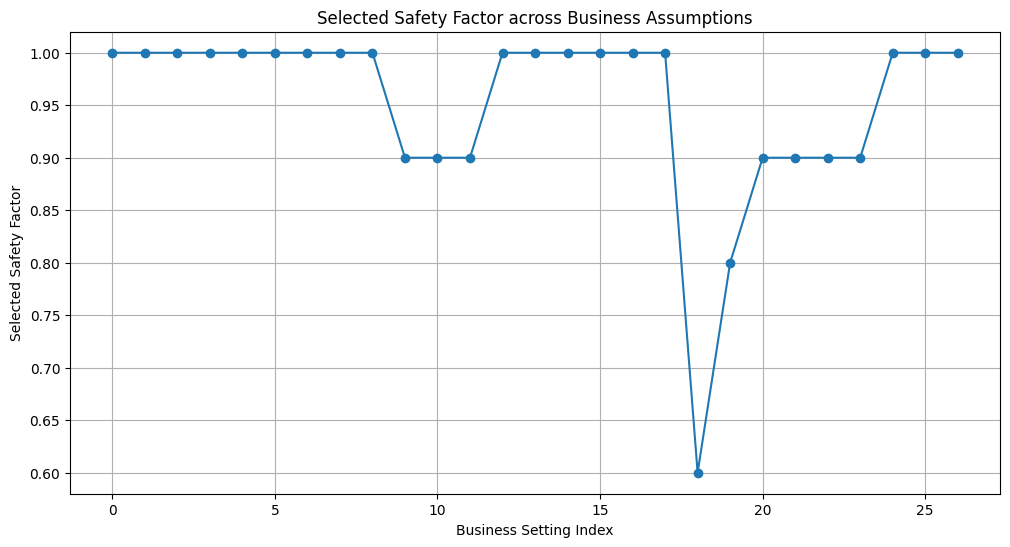

In [9]:
#selected safety factor under each business setting
plt.figure(figsize=(12, 6))

plt.plot(
    range(len(sensitivity_df)),
    sensitivity_df['selected_safety_factor'],
    marker='o'
)

plt.xlabel("Business Setting Index")
plt.ylabel("Selected Safety Factor")
plt.title("Selected Safety Factor across Business Assumptions")
plt.grid(True)
plt.show()

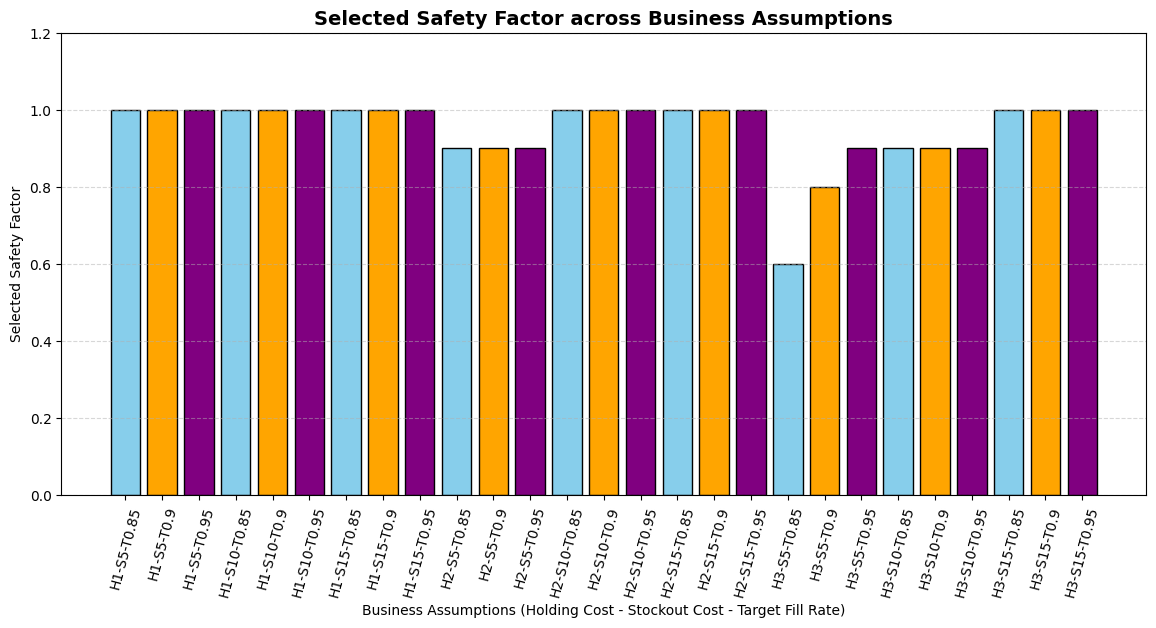

In [10]:
# Create short labels for each business setting
sensitivity_df['setting_label'] = sensitivity_df.apply(
    lambda row: f"H{row['holding_cost']}-S{row['stockout_cost']}-T{row['target_fill_rate']}",
    axis=1
)

plt.figure(figsize=(14, 6))

colors = []
for _, row in sensitivity_df.iterrows():
    if row['target_fill_rate'] == 0.85:
        colors.append('skyblue')
    elif row['target_fill_rate'] == 0.90:
        colors.append('orange')
    else:
        colors.append('purple')

plt.bar(
    sensitivity_df['setting_label'],
    sensitivity_df['selected_safety_factor'],
    color=colors,
    edgecolor='black'
)

plt.xlabel("Business Assumptions (Holding Cost - Stockout Cost - Target Fill Rate)")
plt.ylabel("Selected Safety Factor")
plt.title("Selected Safety Factor across Business Assumptions", fontsize=14, fontweight='bold')
plt.xticks(rotation=75)
plt.ylim(0, 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Safety Factor Sensitivity Observation

The selected safety factor changes across business settings. This shows that the inventory recommendation is not fixed. The framework adjusts the safety buffer depending on holding cost, stockout cost, and target fill rate.

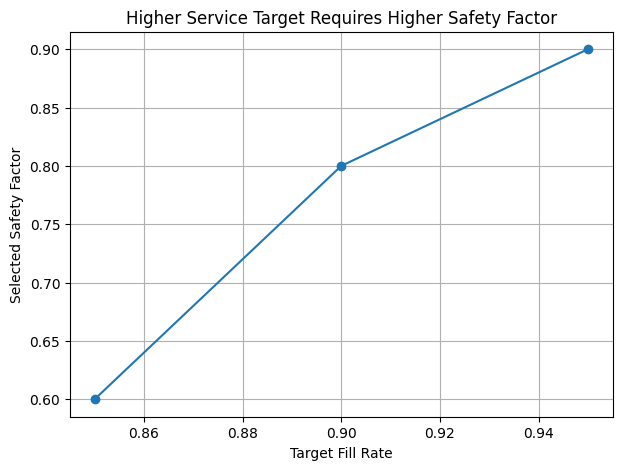

,holding_cost,stockout_cost,target_fill_rate,selected_safety_factor,fill_rate,expected_stockout_units
18,3,5,0.85,0.6,0.851072,4792.483055
19,3,5,0.90,0.8,0.932064,2186.173055
20,3,5,0.95,0.9,0.972541,883.633055


In [11]:
#target fill rate effect for one clear case
target_effect_df = sensitivity_df[
    (sensitivity_df['holding_cost'] == 3) &
    (sensitivity_df['stockout_cost'] == 5)
].copy()

plt.figure(figsize=(7, 5))

plt.plot(
    target_effect_df['target_fill_rate'],
    target_effect_df['selected_safety_factor'],
    marker='o'
)

plt.xlabel("Target Fill Rate")
plt.ylabel("Selected Safety Factor")
plt.title("Higher Service Target Requires Higher Safety Factor")
plt.grid(True)
plt.show()

target_effect_df[
    [
        'holding_cost',
        'stockout_cost',
        'target_fill_rate',
        'selected_safety_factor',
        'fill_rate',
        'expected_stockout_units'
    ]
]

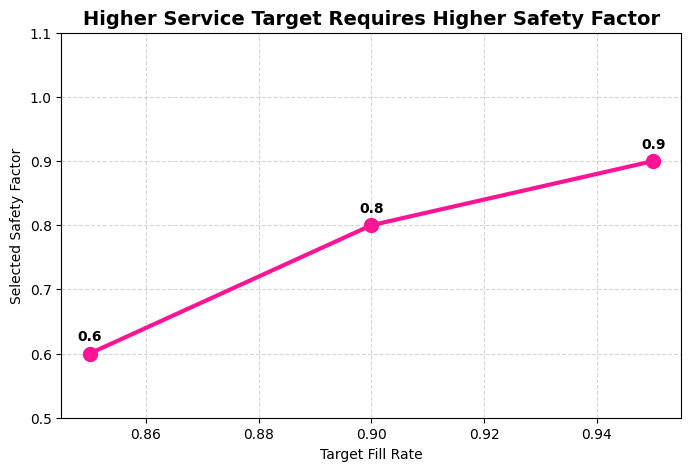

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    target_effect_df['target_fill_rate'],
    target_effect_df['selected_safety_factor'],
    marker='o',
    linewidth=3,
    markersize=10,
    color='deeppink'
)

for x, y in zip(target_effect_df['target_fill_rate'], target_effect_df['selected_safety_factor']):
    plt.text(x, y + 0.02, f"{y:.1f}", ha='center', fontsize=10, fontweight='bold')

plt.xlabel("Target Fill Rate")
plt.ylabel("Selected Safety Factor")
plt.title("Higher Service Target Requires Higher Safety Factor", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0.5, 1.1)
plt.show()

## Service-Level Sensitivity Observation

For the setting where holding cost is 3 and stockout cost is 5, the selected safety factor increases as the target fill rate increases. This is an intuitive and useful result: if a company wants a higher service level, it must accept a larger inventory buffer.

This supports the idea that the framework can translate business service requirements into inventory decisions.

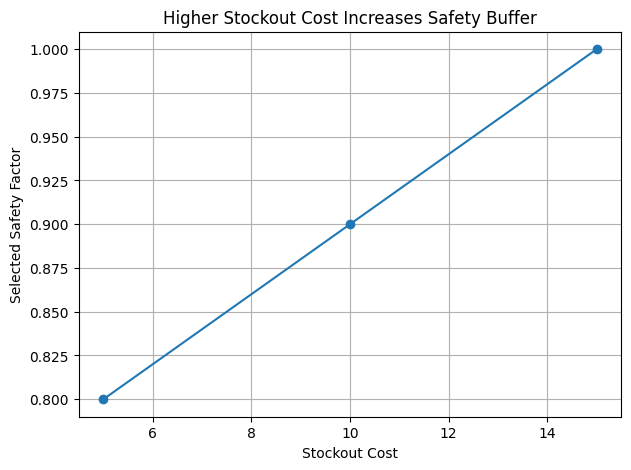

,holding_cost,stockout_cost,target_fill_rate,selected_safety_factor,fill_rate,expected_stockout_units
19,3,5,0.9,0.8,0.932064,2186.173055
22,3,10,0.9,0.9,0.972541,883.633055
25,3,15,0.9,1.0,1.000000,0.000000


In [13]:
#stockout cost effect
stockout_effect_df = sensitivity_df[
    (sensitivity_df['holding_cost'] == 3) &
    (sensitivity_df['target_fill_rate'] == 0.90)
].copy()

plt.figure(figsize=(7, 5))

plt.plot(
    stockout_effect_df['stockout_cost'],
    stockout_effect_df['selected_safety_factor'],
    marker='o'
)

plt.xlabel("Stockout Cost")
plt.ylabel("Selected Safety Factor")
plt.title("Higher Stockout Cost Increases Safety Buffer")
plt.grid(True)
plt.show()

stockout_effect_df[
    [
        'holding_cost',
        'stockout_cost',
        'target_fill_rate',
        'selected_safety_factor',
        'fill_rate',
        'expected_stockout_units'
    ]
]

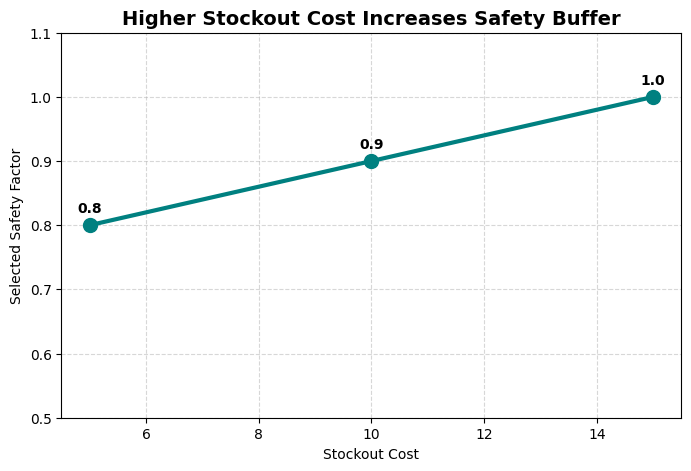

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    stockout_effect_df['stockout_cost'],
    stockout_effect_df['selected_safety_factor'],
    marker='o',
    linewidth=3,
    markersize=10,
    color='teal'
)

for x, y in zip(stockout_effect_df['stockout_cost'], stockout_effect_df['selected_safety_factor']):
    plt.text(x, y + 0.02, f"{y:.1f}", ha='center', fontsize=10, fontweight='bold')

plt.xlabel("Stockout Cost")
plt.ylabel("Selected Safety Factor")
plt.title("Higher Stockout Cost Increases Safety Buffer", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0.5, 1.1)
plt.show()

## Stockout Cost Sensitivity Observation

When stockout cost increases, the selected safety factor also increases. This means the framework becomes more conservative when unmet demand becomes more expensive.

This is business-relevant because firms with high lost-sales penalties or strict service commitments should hold a larger uncertainty buffer than firms where stockouts are less costly.

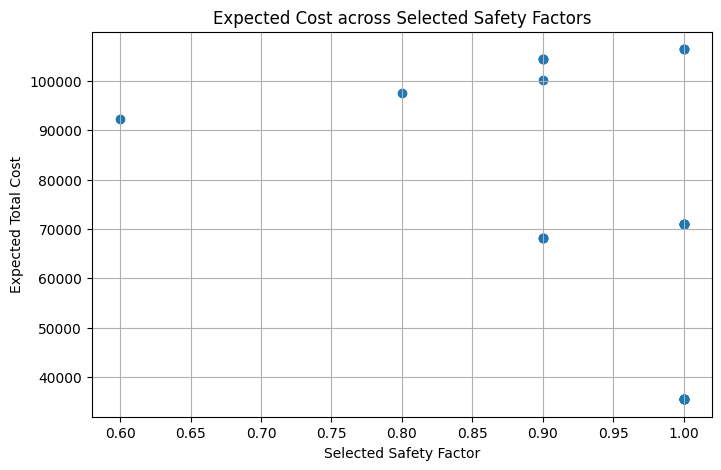

In [15]:
#Graph — expected total cost by selected safety factor
plt.figure(figsize=(8, 5))

plt.scatter(
    sensitivity_df['selected_safety_factor'],
    sensitivity_df['expected_total_cost']
)

plt.xlabel("Selected Safety Factor")
plt.ylabel("Expected Total Cost")
plt.title("Expected Cost across Selected Safety Factors")
plt.grid(True)
plt.show()

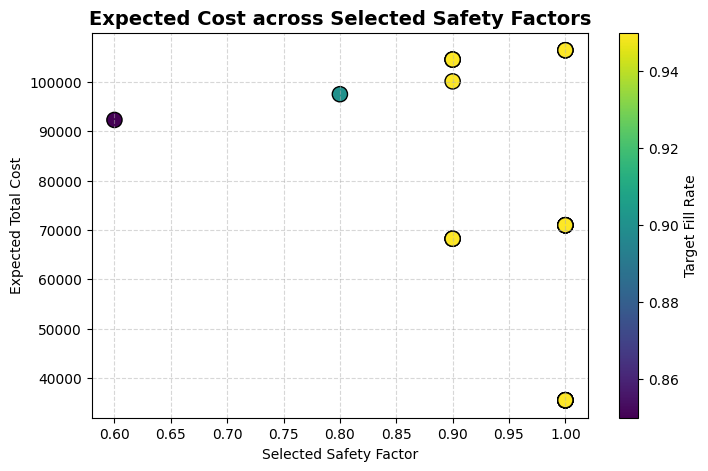

In [16]:
plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    sensitivity_df['selected_safety_factor'],
    sensitivity_df['expected_total_cost'],
    s=120,
    c=sensitivity_df['target_fill_rate'],
    cmap='viridis',
    edgecolors='black'
)

plt.xlabel("Selected Safety Factor")
plt.ylabel("Expected Total Cost")
plt.title("Expected Cost across Selected Safety Factors", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label("Target Fill Rate")

plt.show()

## Cost-Safety Tradeoff Observation

The scatter plot shows the relationship between selected safety factor and expected total cost under different business assumptions. Higher safety factors often increase holding cost, but they can also reduce stockout cost.

This highlights the central tradeoff of the project: inventory decisions should balance cost and service reliability rather than relying on point forecasts alone.

In [17]:
#Final summary table
final_summary = pd.DataFrame({
    "Component": [
        "Forecasting model",
        "Uncertainty layer",
        "Fixed lead-time policy",
        "Lead-time scenario policy",
        "Final sensitivity test"
    ],
    "Result": [
        "LightGBM baseline model trained on intermittent retail demand",
        "Conformal prediction achieved approximately 89.08% empirical coverage for 90% target",
        "Safety factor 0.6 selected under demand uncertainty only",
        "Lead-time scenario policy selected with safety factor 1.0",
        "Policy adapts logically to holding cost, stockout cost, and service target"
    ],
    "Research Meaning": [
        "Point forecasting provides expected demand but struggles with lumpy spikes",
        "Forecast uncertainty is quantified in a distribution-free way",
        "Conformal intervals can be converted into safety stock",
        "Lead-time uncertainty changes the final inventory decision",
        "Recommendation is interpretable and business-adjustable"
    ]
})

final_summary

,Component,Result,Research Meaning
0,Forecasting model,LightGBM baseline model trained on intermitten...,Point forecasting provides expected demand but...
1,Uncertainty layer,Conformal prediction achieved approximately 89...,Forecast uncertainty is quantified in a distri...
2,Fixed lead-time policy,Safety factor 0.6 selected under demand uncert...,Conformal intervals can be converted into safe...
3,Lead-time scenario policy,Lead-time scenario policy selected with safety...,Lead-time uncertainty changes the final invent...
4,Final sensitivity test,"Policy adapts logically to holding cost, stock...",Recommendation is interpretable and business-a...


## Final Conclusion

This notebook tested the final uncertainty-aware inventory decision framework under different business assumptions.

The sensitivity analysis showed that the selected safety factor changes logically with holding cost, stockout cost, and target fill rate. When holding cost is high, the framework avoids unnecessary overstocking. When stockout cost or service-level requirement increases, the framework selects a stronger safety buffer.

This confirms that the final policy is not a black-box recommendation. It is interpretable and adjustable according to business priorities.

Overall, the project completes the full pipeline from machine learning forecasting to inventory decision-making:

LightGBM forecast → conformal uncertainty interval → safety stock signal → lead-time scenario policy → sensitivity-tested final recommendation.

The final result supports the main research argument: inventory optimization should not rely only on point forecasts. Demand uncertainty and lead-time uncertainty both affect the final replenishment policy.


In [18]:
sensitivity_df.to_csv(
    "data/processed/sensitivity_robustness_results.csv",
    index=False
)

final_summary.to_csv(
    "data/processed/final_project_summary.csv",
    index=False
)

print("Saved sensitivity robustness results and final project summary.")

Saved sensitivity robustness results and final project summary.


In [19]:
!git status

Refresh index: 100% (11/11), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/07_lead_time_scenario_policy_engine.ipynb
	modified:   notebooks/08_inventory_policy_optimization_engine.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/09_sensitivity_robustness_final_testing.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
